<a href="https://colab.research.google.com/github/erlanggajuni45/heart-failure-predictive-analytics/blob/main/Predictive_Analytics_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Heart Disease Classification**


## Import Library
Load library yang dibutuhkan

In [31]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Karena data dari kaggle hub, maka perlu didownload dulu

In [32]:
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


Melakukan load data dari dataset 'heart.csv' dan memastikan termuat dengan benar

In [33]:
df = pd.read_csv(path + '/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Menampilkan informasi tentang dataset yang dimuat

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Mencari informasi tentang sebaran data setiap kolomnya

In [35]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


## **Exploratory Data Analysis (EDA)**

memisahkan fitur numerik dan kategorikal

In [36]:
sns.set_theme(style='whitegrid')
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Univariate Analysis fitur numerik

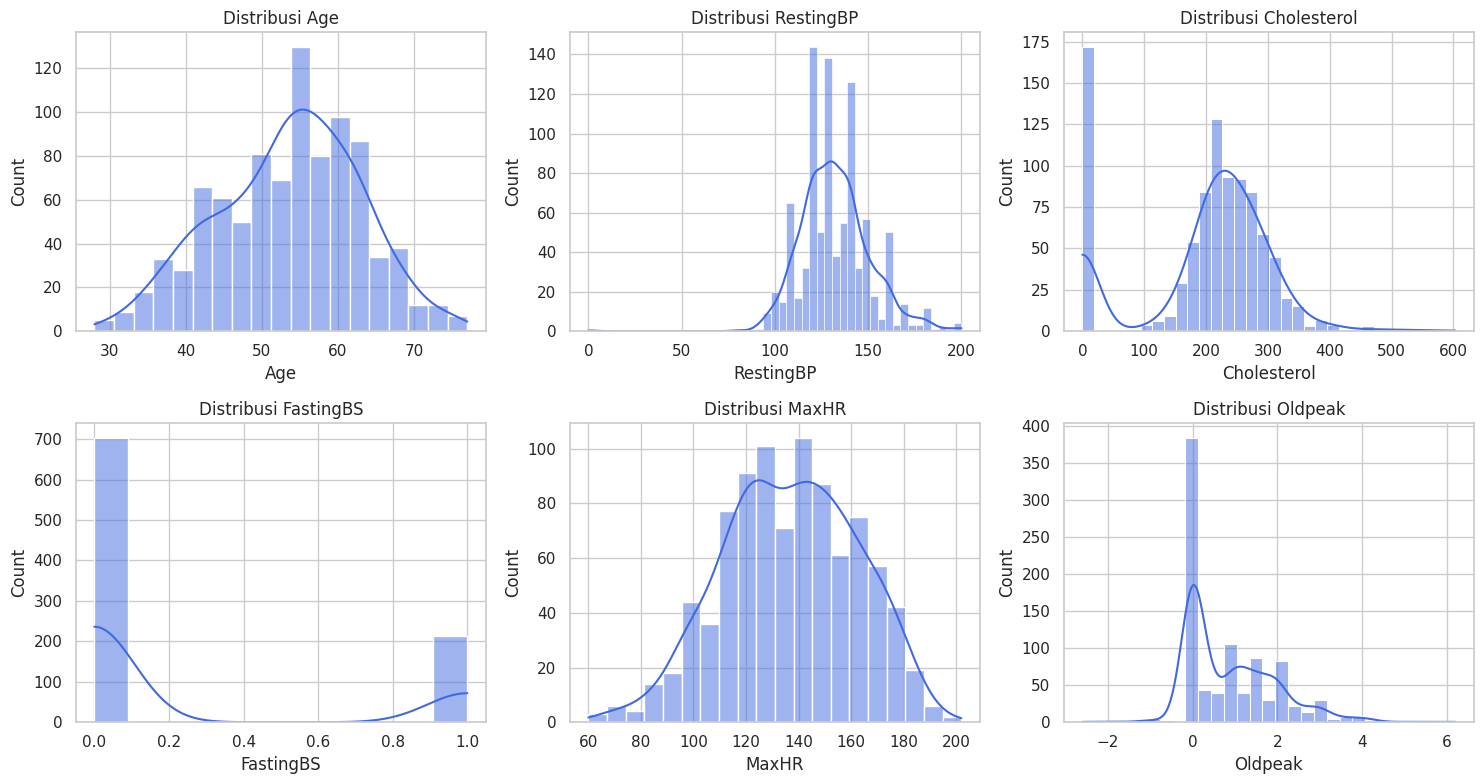

In [37]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
  plt.subplot(2, 3, i)
  sns.histplot(df[col], kde=True, color='royalblue')
  plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

Univariate analysis untuk fitur kategorik

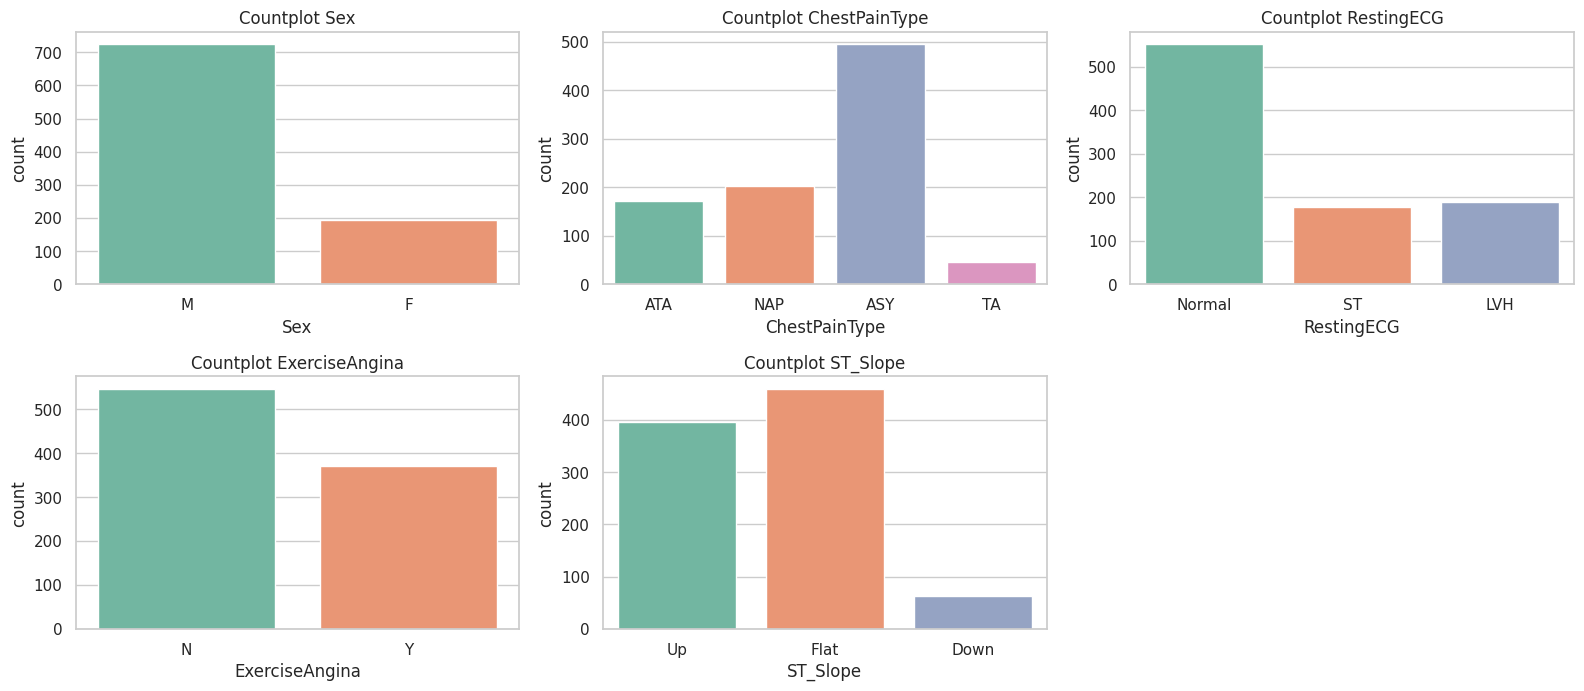

In [38]:
plt.figure(figsize=(16,10))
for i, col in enumerate(categorical_cols, 1):
  plt.subplot(3,3,i)
  sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
  plt.title(f'Countplot {col}')
plt.tight_layout()
plt.show()

Multivariate analysis fitur kategorikal utama dengan Target HeartDisease

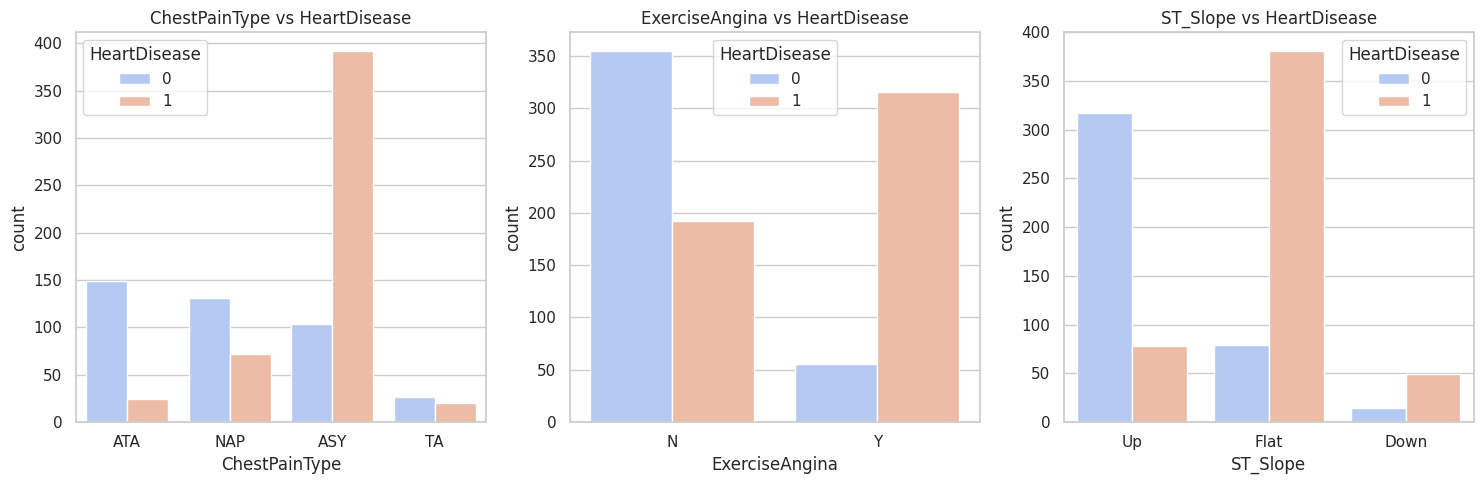

In [39]:
plt.figure(figsize=(15,5))
for i, col in enumerate(['ChestPainType', 'ExerciseAngina', 'ST_Slope'], 1):
  plt.subplot(1,3,i)
  sns.countplot(data=df, x=col, hue='HeartDisease', palette='coolwarm')
  plt.title(f'{col} vs HeartDisease')
plt.tight_layout()
plt.show()

heatmap korelasi numerik dengan fitur target

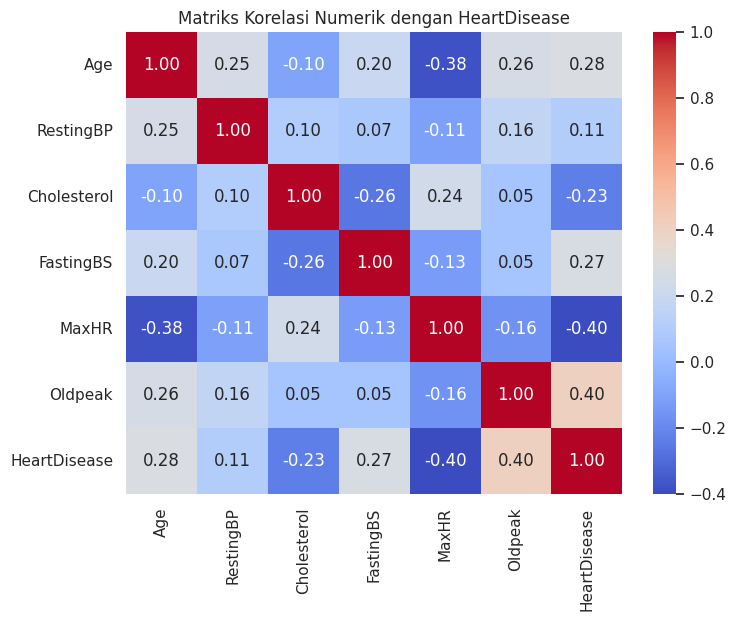

In [40]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols + ['HeartDisease']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Numerik dengan HeartDisease')
plt.show()

## **Data Preparation**

salin dataframe untuk preprocessing

In [41]:
df_clean = df.copy()

imputasi feature restingBP karena tidak make sense tekanan darah nilainya 0. Diganti dengan median

In [42]:
median_bp = df_clean[df_clean['RestingBP'] > 0]['RestingBP'].median()
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, median_bp)

imputasi nilai feature Cholesterol = 0 dengan median

In [43]:
median_chol = df_clean[df_clean['Cholesterol'] > 0]['Cholesterol'].median()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, median_chol)

Encoding fitur kategorikal menggunakan One-Hot Encoding

In [44]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

memisahkan fitur dengan Target

In [45]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

train test split dengan 80% train dan 20% test

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

feature scaling pada fitur numerik (kecuali FastingBS)

In [47]:
nums_cols_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
X_train[nums_cols_to_scale] = scaler.fit_transform(X_train[nums_cols_to_scale])
X_test[nums_cols_to_scale] = scaler.transform(X_test[nums_cols_to_scale])

verifikasi bentuk data

In [48]:
print(f"Jumlah sampel Train: {X_train.shape[0]}, Dimensi Fitur: {X_train.shape[1]}")
print(f"Jumlah sampel Test: {X_test.shape[0]}, Dimensi Fitur: {X_test.shape[1]}")
X_train.head()

Jumlah sampel Train: 734, Dimensi Fitur: 15
Jumlah sampel Test: 184, Dimensi Fitur: 15


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.514028,1,-0.324520,0.317046,True,True,False,False,False,True,True,True,False
486,0.122028,-1.266031,-0.569339,1,1.689837,-0.440356,True,True,False,False,False,True,False,False,True
117,0.546020,-0.159102,1.716858,1,-0.247045,0.601071,False,False,False,False,False,True,True,True,False
361,-0.725956,1.501291,-0.145286,0,-0.479470,-0.819056,True,False,False,False,True,False,True,True,False
296,-0.407962,0.671094,-0.145286,1,0.101594,-0.156330,True,False,False,False,True,False,True,True,False


## **Modeling**

tahap ini akan dilakukan modeling dengan 3 algoritma berbeda dan hyper parameter dengan metode Grid Search. Berikut algoritma yang dipakai:
*  K-Nearest Neighbors (KNN)
*  Random Forest Classifier
*  XGBoost Classifier



import library yang diperlukan

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

inisialisasi model

In [50]:
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

training baseline (tanpa hyperparameter tuning)

In [51]:
knn.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

HyperParameter Tuning pada model Random Forest

In [52]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=param_grid_rf,
                       cv=5,
                       scoring='f1',
                       n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print('Parameter Terbaik Random Forest:', grid_rf.best_params_)

Parameter Terbaik Random Forest: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}


## **Evaluasi**

In [53]:
models = {
    'KNN': knn,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Best Random Forest': best_rf
}
metrics_list = []

prediksi data uji dengan model yang sudah dilatih dan hitung metriknya

In [54]:
for name, model in models.items():
  y_pred = model.predict(X_test)
  y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test,y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan

  metrics_list.append({
      'Model': name,
      'Accuracy': acc,
      'Precision': prec,
      'Recall': rec,
      'F1-Score': f1,
      'ROC-AUC': auc
  })

masukkan ke dataframe untuk perbandingan

In [55]:
df_metrics = pd.DataFrame(metrics_list)
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
print("=== Tabel Perbandingan Kinerja Model pada Data Uji ===")
display(df_metrics.style.highlight_max(color='lightgreen', axis=0, subset=metrics_cols))

=== Tabel Perbandingan Kinerja Model pada Data Uji ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.842391,0.876289,0.833333,0.854271,0.924438
1,Random Forest,0.875000,0.891089,0.882353,0.886700,0.933166
2,XGBoost,0.858696,0.880000,0.862745,0.871287,0.914156
3,Best Random Forest,0.869565,0.890000,0.872549,0.881188,0.929579


visualisasi confusion matrix untuk model terbaik, yaitu Random Forest tanpa hyperparameter tuning

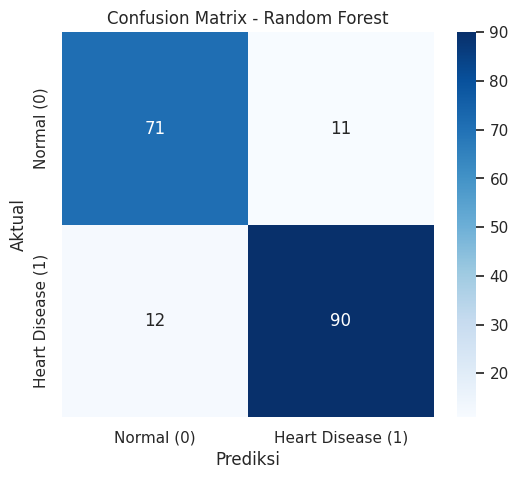

In [56]:
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Heart Disease (1)'],
            yticklabels=['Normal (0)', 'Heart Disease (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [57]:
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf, target_names=['Normal (0)', 'Heart Disease (1)']))


Classification Report (Random Forest):

                   precision    recall  f1-score   support

       Normal (0)       0.86      0.87      0.86        82
Heart Disease (1)       0.89      0.88      0.89       102

         accuracy                           0.88       184
        macro avg       0.87      0.87      0.87       184
     weighted avg       0.88      0.88      0.88       184

